<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #0284c7; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Escalado, Transformación y Normalización de Variables 📐⚖️
      </h1>
      <p style="margin: 6px 0 0 0; color: #0284c7; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Feature Scaling & Transformations
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #0369a1; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 01 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #0284c7; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/02_Escalado_Transformacion_y_Normalizacion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Por qué escalar las variables numéricas 📐

Un modelo de machine learning no "sabe" que `tasa_interes` se mide en puntos porcentuales (rango aproximado 1.2 - 4.5) mientras que `monto_prestamo` se mide en pesos colombianos (rango aproximado 4,348 - 546,672,629). Para el modelo, ambas son simplemente números, y cualquier algoritmo que combine varias columnas en una sola operación matemática —una distancia, un producto punto, un gradiente— termina comparando magnitudes que no son comparables.

**Familias de algoritmos sensibles a la escala:**

* **Basados en distancia:** KNN, K-Means, SVM con kernel RBF — la columna con mayor magnitud absoluta domina el cálculo de distancia, sin importar si es la más relevante para el problema.
* **Basados en gradiente:** regresión lineal/logística con descenso de gradiente, redes neuronales — columnas en escalas muy distintas producen superficies de error alargadas ("valles angostos") que ralentizan o desestabilizan la convergencia.
* **Basados en varianza:** PCA y otras técnicas de reducción de dimensionalidad — al maximizar varianza explícitamente, una columna con valores en el orden de los cientos de millones domina los componentes principales aunque no aporte información útil.

Por el contrario, los **modelos basados en árboles** (Árboles de Decisión, Random Forest, Gradient Boosting) son **invariantes a la escala**: dividen el espacio comparando un valor contra un umbral columna por columna, así que reescalar una variable no cambia en qué orden ni dónde se hacen los cortes. Esto se retomará en la tabla comparativa de la Sección 6.

In [194]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "dataset_crudo_preprocesamiento.csv": "..."
}

def load_dataset(filename="dataset_crudo_preprocesamiento.csv", module_name="01 - Preprocesamiento de los Datos"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo restaura automáticamente de forma exacta.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("..", "..", "data", filename),
        os.path.join("Data Mining", module_name, "data", filename),
        os.path.join("..", "Data Mining", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path

    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Mining/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)

    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]

    print(f"[INFO] Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=2) as response:
                if response.status == 200:
                    with open(target_path, "wb") as out_f:
                        out_f.write(response.read())
                    print(f"[OK] Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue

    if filename in _DATA_EMBEDDED:
        print(f"[INFO] Restaurando '{filename}' de forma autonoma...")
        data_bytes = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target_path, "wb") as out_f:
            out_f.write(data_bytes)
        print(f"[OK] Dataset '{filename}' preparado exitosamente en '{target_path}'.")
        return target_path

    raise FileNotFoundError(f"No se pudo encontrar ni generar el dataset '{filename}'.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(load_dataset("dataset_crudo_preprocesamiento.csv"))

columnas_numericas = ["edad", "ingreso_mensual", "score_credito", "tasa_interes", "monto_prestamo"]
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\nRango (min - max) de cada columna numerica:")
display(df[columnas_numericas].describe().loc[["min", "max"]])

Dimensiones del dataset: 2000 filas x 8 columnas

Rango (min - max) de cada columna numerica:


,edad,ingreso_mensual,score_credito,tasa_interes,monto_prestamo
min,-3.00,"1,012.34",394.00,1.20,"4,348.32"
max,150.00,"95,000,000.00",850.00,4.50,"546,672,629.13"


### 1.1 Demostración concreta: una distancia euclidiana dominada por una sola columna 🔍

Para que el argumento anterior no quede en teoría, se calcula la **distancia euclidiana** entre dos clientes reales del dataset usando solamente `ingreso_mensual` y `tasa_interes` **sin escalar**. Si el escalado no importara, ambas columnas deberían aportar una fracción razonable de esa distancia.

In [195]:
pares = df.dropna(subset=["ingreso_mensual", "tasa_interes"])[["ingreso_mensual", "tasa_interes"]]
fila_a = pares.iloc[0]
fila_b = pares.iloc[1]

diff_ingreso = fila_a["ingreso_mensual"] - fila_b["ingreso_mensual"]
diff_tasa = fila_a["tasa_interes"] - fila_b["tasa_interes"]

aporte_ingreso = diff_ingreso ** 2
aporte_tasa = diff_tasa ** 2
distancia_cruda = np.sqrt(aporte_ingreso + aporte_tasa)

print(f"Cliente A: ingreso_mensual={fila_a['ingreso_mensual']:,.2f} | tasa_interes={fila_a['tasa_interes']:.2f}")
print(f"Cliente B: ingreso_mensual={fila_b['ingreso_mensual']:,.2f} | tasa_interes={fila_b['tasa_interes']:.2f}")
print(f"\nDistancia euclidiana SIN escalar: {distancia_cruda:,.2f}")
print(f"Aporte al cuadrado de ingreso_mensual: {aporte_ingreso:,.2f}")
print(f"Aporte al cuadrado de tasa_interes:    {aporte_tasa:,.4f}")
print(f"% de la distancia (al cuadrado) explicado por tasa_interes: {aporte_tasa / (aporte_ingreso + aporte_tasa) * 100:.10f}%")

Cliente A: ingreso_mensual=21,901,987.81 | tasa_interes=1.23
Cliente B: ingreso_mensual=4,774,766.59 | tasa_interes=2.66

Distancia euclidiana SIN escalar: 17,127,221.22
Aporte al cuadrado de ingreso_mensual: 293,341,706,718,818.25
Aporte al cuadrado de tasa_interes:    2.0449
% de la distancia (al cuadrado) explicado por tasa_interes: 0.0000000000%


`tasa_interes` explica una fracción prácticamente nula (muy por debajo de 0.001%) de la distancia total, aunque en términos de negocio una diferencia de 1.43 puntos porcentuales en la tasa de interés es perfectamente relevante para comparar dos clientes. Un KNN o un K-Means que use estas dos columnas sin escalar está en la práctica **ignorando `tasa_interes` por completo**. Ahora se repite el cálculo tras aplicar `StandardScaler` a ambas columnas.

In [196]:
scaler_demo = StandardScaler()
pares_escalados = scaler_demo.fit_transform(pares)

diff_ingreso_z = pares_escalados[0, 0] - pares_escalados[1, 0]
diff_tasa_z = pares_escalados[0, 1] - pares_escalados[1, 1]

aporte_ingreso_z = diff_ingreso_z ** 2
aporte_tasa_z = diff_tasa_z ** 2
distancia_escalada = np.sqrt(aporte_ingreso_z + aporte_tasa_z)

print(f"Distancia euclidiana CON StandardScaler: {distancia_escalada:.4f}")
print(f"Aporte al cuadrado de ingreso_mensual (escalado): {aporte_ingreso_z:.4f}")
print(f"Aporte al cuadrado de tasa_interes (escalado):    {aporte_tasa_z:.4f}")
print(f"% de la distancia (al cuadrado) explicado por tasa_interes: {aporte_tasa_z / (aporte_ingreso_z + aporte_tasa_z) * 100:.2f}%")

Distancia euclidiana CON StandardScaler: 2.5568
Aporte al cuadrado de ingreso_mensual (escalado): 4.2806
Aporte al cuadrado de tasa_interes (escalado):    2.2564
% de la distancia (al cuadrado) explicado por tasa_interes: 34.52%


Tras escalar, `tasa_interes` pasa de explicar una fracción insignificante de la distancia a explicar cerca de una tercera parte de ella — una participación mucho más razonable dado que ambas variables aportan información de negocio. Este es precisamente el problema que resuelven los escaladores de esta sección.

### 1.2 Prerrequisito práctico: imputar antes de escalar

Los escaladores de scikit-learn no aceptan valores `NaN`. Como se detalló en el **Cuaderno 00 (Tratamiento de Valores Faltantes)**, varias columnas numéricas de este dataset tienen nulos (`edad`, `ingreso_mensual`, `score_credito`, `monto_prestamo`). Aquí no se repite ese análisis —solo se aplica una imputación simple por mediana, ya justificada en el Cuaderno 00 por la fuerte asimetría de estas columnas— para tener un dataframe numéricamente completo (`df_prep`) sobre el cual demostrar cada técnica de escalado.

In [197]:
imputer_num = SimpleImputer(strategy="median")
df_prep = df.copy()
cols_a_imputar = ["edad", "ingreso_mensual", "score_credito", "monto_prestamo"]
df_prep[cols_a_imputar] = imputer_num.fit_transform(df[cols_a_imputar])

print("Nulos por columna numerica ANTES de imputar:")
print(df[columnas_numericas].isnull().sum().to_string())
print("\nNulos por columna numerica DESPUES de imputar (df_prep):")
print(df_prep[columnas_numericas].isnull().sum().to_string())

Nulos por columna numerica ANTES de imputar:
edad                79
ingreso_mensual    119
score_credito       50
tasa_interes         0
monto_prestamo     119

Nulos por columna numerica DESPUES de imputar (df_prep):
edad               0
ingreso_mensual    0
score_credito      0
tasa_interes       0
monto_prestamo     0


---
## 2. `StandardScaler`: Estandarización Z-score 📊

`StandardScaler` centra cada columna en media 0 y la reescala a desviación estándar 1:

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar **de la muestra sobre la que se hace `fit`**. El resultado no tiene un rango acotado (puede producir valores muy negativos o muy positivos si hay outliers extremos), pero preserva la forma de la distribución original —solo la traslada y reescala— y es el escalador de referencia para algoritmos basados en gradiente y para PCA.

In [198]:
scaler_std = StandardScaler()
cols_escalar = ["ingreso_mensual", "monto_prestamo"]
datos_std = scaler_std.fit_transform(df_prep[cols_escalar])
df_std = pd.DataFrame(datos_std, columns=[c + "_std" for c in cols_escalar], index=df_prep.index)

print("Media y desviacion estandar ANTES de escalar:")
display(df_prep[cols_escalar].agg(["mean", "std"]))
print("\nMedia y desviacion estandar DESPUES de StandardScaler:")
display(df_std.agg(["mean", "std"]))

Media y desviacion estandar ANTES de escalar:


,ingreso_mensual,monto_prestamo
mean,"4,443,293.37","19,268,008.24"
std,"8,042,177.30","37,979,448.36"



Media y desviacion estandar DESPUES de StandardScaler:


,ingreso_mensual_std,monto_prestamo_std
mean,-0.00,0.00
std,1.00,1.00


<Axes: xlabel='ingreso_mensual', ylabel='Count'>

Text(0.5, 1.0, 'ingreso_mensual -- ANTES (escala original)')

<Axes: xlabel='ingreso_mensual_std', ylabel='Count'>

Text(0.5, 1.0, 'ingreso_mensual -- DESPUES de StandardScaler')

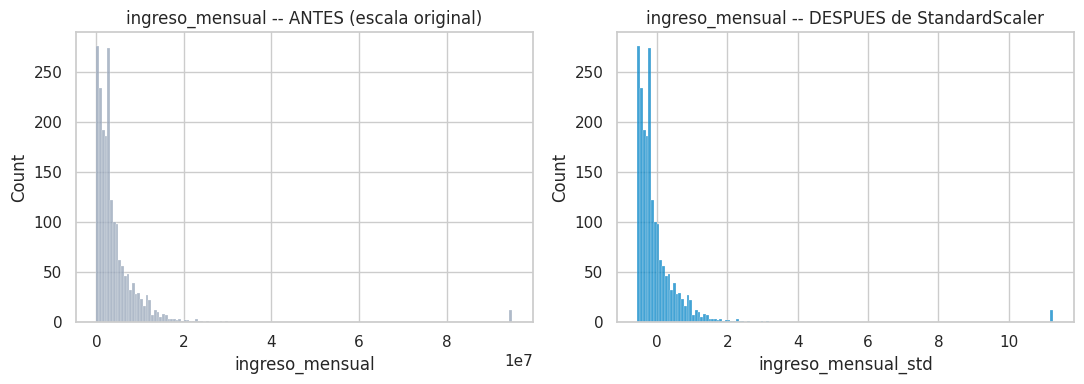

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_prep["ingreso_mensual"], color="#94a3b8", kde=False, ax=axes[0])
axes[0].set_title("ingreso_mensual -- ANTES (escala original)")
sns.histplot(df_std["ingreso_mensual_std"], color="#0284c7", kde=False, ax=axes[1])
axes[1].set_title("ingreso_mensual -- DESPUES de StandardScaler")
plt.tight_layout()
plt.show()

La media prácticamente en 0 y la desviación estándar en 1 confirman la definición matemática del método. Nótese que el **histograma no cambia de forma**: `StandardScaler` es una transformación afín (traslación + reescalado), no corrige la asimetría de la distribución —eso es tarea del `PowerTransformer` de la Sección 5.

---
## 3. `MinMaxScaler`: Escalado a un rango acotado 📐

`MinMaxScaler` comprime linealmente cada columna al rango $[0, 1]$ (o a cualquier otro rango explícito vía el parámetro `feature_range`):

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Cuándo preferirlo:** cuando el algoritmo espera entradas en un rango acotado — por ejemplo, capas de entrada de redes neuronales con funciones de activación sigmoide, o algoritmos de visión por computador que trabajan con píxeles normalizados.

**Su debilidad:** el rango completo depende únicamente de **dos** observaciones, `x_min` y `x_max`. Un solo outlier extremo en cualquiera de los dos extremos estira el denominador y comprime a casi todo el resto del dataset contra un extremo del rango — se demuestra a continuación con `monto_prestamo`, que tiene un máximo de ¡546,672,629 pesos!

In [200]:
scaler_mm = MinMaxScaler()
datos_mm = scaler_mm.fit_transform(df_prep[cols_escalar])
df_mm = pd.DataFrame(datos_mm, columns=[c + "_mm" for c in cols_escalar], index=df_prep.index)

print("Rango ANTES de escalar:")
display(df_prep[cols_escalar].agg(["min", "max"]))
print("\nRango DESPUES de MinMaxScaler (por definicion, siempre [0, 1]):")
display(df_mm.agg(["min", "max"]))

pct_bajo = (df_mm["monto_prestamo_mm"] < 0.05).mean() * 100
print(f"\n% de registros de monto_prestamo comprimidos por debajo de 0.05 tras MinMaxScaler: {pct_bajo:.2f}%")

Rango ANTES de escalar:


,ingreso_mensual,monto_prestamo
min,"1,012.34","4,348.32"
max,"95,000,000.00","546,672,629.13"



Rango DESPUES de MinMaxScaler (por definicion, siempre [0, 1]):


,ingreso_mensual_mm,monto_prestamo_mm
min,0.00,0.00
max,1.00,1.00



% de registros de monto_prestamo comprimidos por debajo de 0.05 tras MinMaxScaler: 81.30%


Aunque el rango final es exactamente $[0, 1]$ como promete la fórmula, más del 80% de los préstamos terminan apretujados en el primer 5% de ese rango —porque el máximo de la columna lo fija un único cliente con un préstamo extraordinariamente alto—. Para la mayoría de los algoritmos, esto destruye casi toda la capacidad de distinguir entre préstamos "pequeños" y "medianos".

---
## 4. `RobustScaler`: Escalado robusto a outliers 🛡️

`RobustScaler` reemplaza la media y la desviación estándar por estadísticos **robustos**: la mediana y el rango intercuartílico (IQR = Q3 - Q1).

$$x' = \frac{x - \text{mediana}}{IQR}$$

Ni la mediana ni el IQR se mueven apreciablemente aunque el valor máximo de la columna se multiplique por diez —a diferencia de la media y la desviación estándar (usadas por `StandardScaler`) o el máximo (usado por `MinMaxScaler`), que sí son arrastrados por un solo valor extremo. Esto hace de `RobustScaler` la opción natural para columnas financieras como `monto_prestamo`, que en la Sección 3 mostró tener un outlier que domina por completo el rango.

In [201]:
scaler_rob = RobustScaler()
datos_rob = scaler_rob.fit_transform(df_prep[["monto_prestamo"]])
serie_rob = pd.Series(datos_rob.ravel(), index=df_prep.index, name="monto_prestamo_robust")

serie_std_monto = df_std["monto_prestamo_std"]
serie_mm_monto = df_mm["monto_prestamo_mm"]

pct_std_centro = ((serie_std_monto >= -1) & (serie_std_monto <= 1)).mean() * 100
pct_rob_centro = ((serie_rob >= -1) & (serie_rob <= 1)).mean() * 100

print("Comparacion: que tanto 'comprime' cada escalador la mayoria de los datos de monto_prestamo")
print(f"  StandardScaler -> % de valores en [-1, 1]: {pct_std_centro:.2f}%  | rango total: [{serie_std_monto.min():.2f}, {serie_std_monto.max():.2f}]")
print(f"  RobustScaler   -> % de valores en [-1, 1]: {pct_rob_centro:.2f}%  | rango total: [{serie_rob.min():.2f}, {serie_rob.max():.2f}]")
print(f"\n  Mediana bajo RobustScaler: {np.median(datos_rob):.4f} (por definicion, siempre 0)")
print(f"  Q1 bajo RobustScaler: {np.percentile(datos_rob, 25):.4f} | Q3 bajo RobustScaler: {np.percentile(datos_rob, 75):.4f} (por definicion, siempre -0.5 y 0.5)")

Comparacion: que tanto 'comprime' cada escalador la mayoria de los datos de monto_prestamo
  StandardScaler -> % de valores en [-1, 1]: 95.40%  | rango total: [-0.51, 13.89]
  RobustScaler   -> % de valores en [-1, 1]: 82.10%  | rango total: [-0.68, 31.97]

  Mediana bajo RobustScaler: 0.0000 (por definicion, siempre 0)
  Q1 bajo RobustScaler: -0.3731 | Q3 bajo RobustScaler: 0.6269 (por definicion, siempre -0.5 y 0.5)


El punto no es que el outlier se vea "menos extremo" bajo `RobustScaler` —de hecho, en unidades de IQR el máximo llega a estar a más de 31 unidades del centro, más lejos que las cerca de 14 desviaciones estándar que marca `StandardScaler`—. El punto es que la mediana y el IQR **no dependen del outlier para calcularse**, así que el 50% central de los datos (entre Q1 y Q3) siempre queda mapeado exactamente al intervalo $[-0.5, 0.5]$, sin importar qué tan extremo sea el máximo. Bajo `StandardScaler`, en cambio, ese mismo outlier infla tanto la media como la desviación estándar, y termina aplastando a la mayoría de las observaciones "normales" cerca de 0 —perdiendo la capacidad de distinguirlas entre sí—.

---
## 5. `PowerTransformer` (Yeo-Johnson): Estabilizar varianza y aproximar a una normal 📈

Ni `StandardScaler`, ni `MinMaxScaler`, ni `RobustScaler` cambian la **forma** de la distribución —son transformaciones lineales (afines). Cuando un algoritmo asume (implícita o explícitamente) que las variables se distribuyen de forma aproximadamente normal —regresión lineal clásica, LDA, algunos modelos bayesianos— una columna fuertemente asimétrica sigue siendo un problema incluso después de escalarla linealmente.

`PowerTransformer(method="yeo-johnson")` aplica una familia de transformaciones no lineales paramétricas (parámetro $\lambda$ estimado por máxima verosimilitud) diseñadas para **reducir la asimetría y estabilizar la varianza**, acercándose a una forma gaussiana. A diferencia de la transformación Box-Cox (su predecesora), Yeo-Johnson **admite valores negativos y cero**, por lo que no exige que la columna sea estrictamente positiva. Además, `PowerTransformer` estandariza internamente la salida (media 0, varianza 1) por defecto.

In [202]:
print(f"Asimetria (skew) de monto_prestamo ANTES de transformar: {df_prep['monto_prestamo'].skew():.2f}")
print(f"Asimetria (skew) de ingreso_mensual ANTES de transformar: {df_prep['ingreso_mensual'].skew():.2f}")
print("(como referencia: una distribucion normal tiene skew = 0; valores > 1 se consideran fuertemente asimetricos)")

pt = PowerTransformer(method="yeo-johnson")
datos_pt = pt.fit_transform(df_prep[["monto_prestamo"]])
serie_pt = pd.Series(datos_pt.ravel(), index=df_prep.index, name="monto_prestamo_yj")

print(f"\nLambda estimado por PowerTransformer para monto_prestamo: {pt.lambdas_[0]:.4f}")
print(f"Asimetria (skew) de monto_prestamo DESPUES de Yeo-Johnson: {serie_pt.skew():.2f}")

Asimetria (skew) de monto_prestamo ANTES de transformar: 9.68
Asimetria (skew) de ingreso_mensual ANTES de transformar: 8.76
(como referencia: una distribucion normal tiene skew = 0; valores > 1 se consideran fuertemente asimetricos)

Lambda estimado por PowerTransformer para monto_prestamo: 0.1690
Asimetria (skew) de monto_prestamo DESPUES de Yeo-Johnson: 0.10


<Axes: xlabel='monto_prestamo', ylabel='Count'>

Text(0.5, 1.0, 'monto_prestamo -- ANTES (skew ~9.7, fuertemente asimetrico)')

<Axes: xlabel='monto_prestamo_yj', ylabel='Count'>

Text(0.5, 1.0, 'monto_prestamo -- DESPUES de Yeo-Johnson (skew ~0.10)')

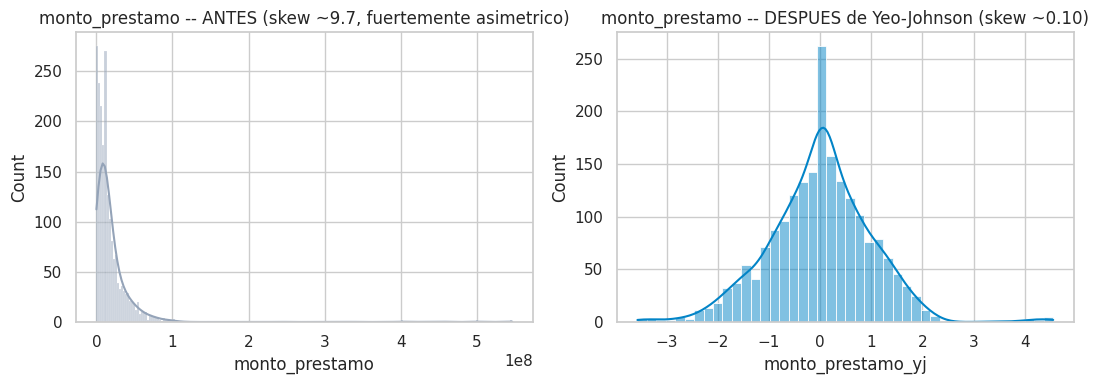

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_prep["monto_prestamo"], color="#94a3b8", kde=True, ax=axes[0])
axes[0].set_title("monto_prestamo -- ANTES (skew ~9.7, fuertemente asimetrico)")
sns.histplot(serie_pt, color="#0284c7", kde=True, ax=axes[1])
axes[1].set_title("monto_prestamo -- DESPUES de Yeo-Johnson (skew ~0.10)")
plt.tight_layout()
plt.show()

La asimetría cae de un valor extremo (~9.7, producto de la larga cola derecha de préstamos muy altos) a un valor cercano a 0 (~0.10), y el histograma pasa de una forma unimodal muy comprimida hacia la izquierda a una forma mucho más parecida a una campana gaussiana. Esta transformación es especialmente útil como paso previo a modelos lineales o a métodos que asumen normalidad, y suele combinarse —no sustituir— con los escaladores anteriores según la necesidad del pipeline.

---
## 6. Tabla comparativa de escaladores 📋

| Técnica | Fórmula | Rango de salida | Sensibilidad a outliers | Cuándo usarla |
|---|---|---|---|---|
| **StandardScaler** | $z = (x-\mu)/\sigma$ | No acotado (típicamente ~[-3, 3]) | **Alta** — media y std se inflan con outliers | Regresión/clasificación con descenso de gradiente, SVM, PCA, cuando la columna es aproximadamente simétrica |
| **MinMaxScaler** | $(x-x_{min})/(x_{max}-x_{min})$ | Acotado $[0, 1]$ exacto | **Muy alta** — depende solo de 2 puntos (min y max) | Redes neuronales, imágenes, cuando se necesita estrictamente un rango acotado y no hay outliers severos |
| **RobustScaler** | $(x-\text{mediana})/IQR$ | No acotado, pero el 50% central cae siempre en $[-0.5, 0.5]$ | **Baja** — mediana e IQR ignoran los extremos | Columnas financieras/con outliers legítimos (montos, ingresos) que no se quieren eliminar pero tampoco deben dominar la escala |
| **PowerTransformer (Yeo-Johnson)** | Familia paramétrica no lineal en $\lambda$ | No acotado, aproximadamente $\mathcal{N}(0,1)$ | Media — reduce la influencia de la cola, pero no es su objetivo principal | Cuando el algoritmo asume normalidad, o la asimetría extrema (skew alto) distorsiona el modelo más allá de lo que corrige un escalado lineal |

**Nota importante:** los modelos basados en árboles (Árbol de Decisión, Random Forest, Gradient Boosting/XGBoost/LightGBM) **no requieren escalado en absoluto** — dividen usando umbrales por columna, y un umbral óptimo en la escala original sigue siendo óptimo tras cualquier transformación monótona. Escalar antes de un árbol no perjudica el resultado, pero tampoco lo mejora; es un paso que se puede omitir con seguridad para esa familia de modelos.

---
## 7. El error más costoso: ajustar (`fit`) el escalador con datos de prueba ⚠️

Un escalador **aprende** sus parámetros (media/std, min/max, mediana/IQR, $\lambda$) a partir de los datos sobre los que se llama `.fit()`. Si ese `fit` incluye observaciones del conjunto de prueba (o de producción futura), el modelo termina "viendo" indirectamente información de datos que se suponía debían permanecer desconocidos durante el entrenamiento —esto es **fuga de datos (data leakage)** y produce estimaciones de desempeño optimistas que no se sostienen en producción.

**Regla:** `fit()` (o `fit_transform()`) se llama **solo sobre el conjunto de entrenamiento**. Sobre el conjunto de prueba —y sobre cualquier dato nuevo que llegue después— se llama únicamente `.transform()`, reutilizando los parámetros ya aprendidos.

In [204]:
X_train, X_test = train_test_split(df_prep[["ingreso_mensual"]], test_size=0.2, random_state=42)

# CORRECTO: fit() solo sobre train, luego transform() sobre train y test
scaler_correcto = StandardScaler()
scaler_correcto.fit(X_train)
test_correcto = scaler_correcto.transform(X_test)

# INCORRECTO: fit_transform() sobre train+test juntos -> el escalador "ve" el test antes de tiempo
scaler_incorrecto = StandardScaler()
datos_completos_escalados = scaler_incorrecto.fit_transform(df_prep[["ingreso_mensual"]])
serie_incorrecta = pd.Series(datos_completos_escalados.ravel(), index=df_prep.index)
test_incorrecto = serie_incorrecta.loc[X_test.index].values

print(f"Media de ingreso_mensual aprendida SOLO con train (80% de los datos): {scaler_correcto.mean_[0]:,.2f}")
print(f"Media de ingreso_mensual aprendida con train+test (100% de los datos): {scaler_incorrecto.mean_[0]:,.2f}")
print(f"Diferencia entre ambas medias: {abs(scaler_correcto.mean_[0] - scaler_incorrecto.mean_[0]):,.2f}")

print("\nPrimeros 3 valores de X_test escalados CORRECTAMENTE (transform con estadisticos de train):")
print(np.round(test_correcto[:3].ravel(), 4))
print("Primeros 3 valores de X_test escalados INCORRECTAMENTE (fit_transform con fuga de test):")
print(np.round(test_incorrecto[:3], 4))

StandardScaler()

Media de ingreso_mensual aprendida SOLO con train (80% de los datos): 4,376,223.92
Media de ingreso_mensual aprendida con train+test (100% de los datos): 4,443,293.37
Diferencia entre ambas medias: 67,069.46

Primeros 3 valores de X_test escalados CORRECTAMENTE (transform con estadisticos de train):
[-0.214  -0.214  -0.3101]
Primeros 3 valores de X_test escalados INCORRECTAMENTE (fit_transform con fuga de test):
[-0.2176 -0.2176 -0.3115]


Aunque en este ejemplo la diferencia numérica entre ambas medias es moderada, en datasets más pequeños o con outliers concentrados en el conjunto de prueba la diferencia puede ser sustancial —y, más importante, el principio es el mismo sin importar la magnitud: **cualquier fuga, por pequeña que parezca, invalida la evaluación honesta del modelo**. En un `Pipeline` de scikit-learn, este orden correcto (`fit` en train, `transform` en test) se garantiza automáticamente siempre que el pipeline completo —incluyendo el escalador— se ajuste con `.fit(X_train, y_train)` y se evalúe con `.transform(X_test)` o `.predict(X_test)`, nunca con `.fit_transform()` sobre el dataset completo.

---
## 8. Ejercicio práctico guiado: comparar escaladores sobre `tasa_interes` 📝

**Contexto:** `tasa_interes` no tiene valores nulos y, a diferencia de `monto_prestamo`, es una columna razonablemente simétrica (sin outliers extremos). Es un buen caso para comparar dos escaladores sin la complicación de outliers de por medio.

**Tu misión:**
1. Crea un `MinMaxScaler` y un `StandardScaler`.
2. Ajusta y transforma la columna `tasa_interes` con cada uno (usa doble corchete: `df_prep[["tasa_interes"]]`).
3. Imprime el rango (min, max) resultante de `MinMaxScaler` y la media/desviación estándar resultante de `StandardScaler`.
4. En un comentario dentro de tu celda, responde: si vas a alimentar esta columna como entrada a una red neuronal con activación sigmoide en la primera capa, ¿cuál de los dos escaladores es la elección natural y por qué?

In [205]:
### TU CODIGO AQUI ###
# 1. Crea los dos escaladores
scaler_mm_ej = None
scaler_std_ej = None

# 2. Ajusta y transforma tasa_interes con cada uno
tasa_mm = None
tasa_std = None

# 3. Imprime rango de MinMaxScaler y media/std de StandardScaler
print("MinMaxScaler -> min:", None, "max:", None)
print("StandardScaler -> media:", None, "std:", None)

# 4. Respuesta en comentario:
# ...

MinMaxScaler -> min: None max: None
StandardScaler -> media: None std: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Crea los dos escaladores
scaler_mm_ej = MinMaxScaler()
scaler_std_ej = StandardScaler()

# 2. Ajusta y transforma tasa_interes con cada uno
tasa_mm = scaler_mm_ej.fit_transform(df_prep[["tasa_interes"]])
tasa_std = scaler_std_ej.fit_transform(df_prep[["tasa_interes"]])

# 3. Imprime rango de MinMaxScaler y media/std de StandardScaler
print("MinMaxScaler -> min:", tasa_mm.min(), "max:", tasa_mm.max())
print("StandardScaler -> media:", tasa_std.mean(), "std:", tasa_std.std())

# 4. Respuesta:
# MinMaxScaler es la eleccion natural para una red neuronal con activacion sigmoide,
# porque la sigmoide mapea su entrada a un rango acotado [0, 1] y las redes convergen
# mejor cuando todas las entradas comparten un rango numerico similar y acotado.
# StandardScaler no garantiza un rango maximo/minimo fijo, lo cual es menos ideal
# para esta arquitectura especifica (aunque funciona bien en muchas otras).
```

</details>

---
## 9. Resumen Ejecutivo del Cuaderno 02 📌

1. **El escalado no es cosmético:** algoritmos basados en distancia, gradiente o varianza combinan columnas en una sola operación matemática, y una columna con mayor magnitud absoluta (`ingreso_mensual` o `monto_prestamo` frente a `tasa_interes`) domina el resultado si no se homogeniza la escala —se demostró con una distancia euclidiana donde `tasa_interes` pasaba de explicar ~0% a ~34% de la distancia total tras estandarizar.
2. **`StandardScaler`** centra en media 0 / desviación 1 y es la opción por defecto para modelos basados en gradiente y PCA, pero sus estadísticos (media y std) se distorsionan con outliers.
3. **`MinMaxScaler`** garantiza un rango exacto $[0,1]$, ideal para redes neuronales, pero es extremadamente sensible a los valores mínimo y máximo — en `monto_prestamo`, un solo outlier comprimió más del 80% de los registros por debajo de 0.05.
4. **`RobustScaler`** usa mediana e IQR en lugar de media y std, por lo que el outlier extremo de `monto_prestamo` no distorsiona el escalado del resto de los datos — el 50% central siempre cae en $[-0.5, 0.5]$ sin importar qué tan lejos esté el máximo.
5. **`PowerTransformer` (Yeo-Johnson)** corrige la **forma** de la distribución (no solo su escala): redujo la asimetría de `monto_prestamo` de ~9.7 a ~0.10, acercándola a una campana gaussiana, y admite valores negativos o cero a diferencia de Box-Cox.
6. **Los modelos basados en árboles no necesitan escalado** — es seguro omitirlo para Random Forest, Gradient Boosting, etc.
7. **La regla de oro contra la fuga de datos:** `fit()` (o `fit_transform()`) únicamente sobre el conjunto de entrenamiento; `.transform()` —nunca `fit_transform()`— sobre el conjunto de prueba y sobre cualquier dato nuevo.
8. **Siguiente paso:** el **Cuaderno 03** aborda la **codificación de variables categóricas** (`escolaridad`, `canal_contacto`) de este mismo dataset, el otro gran prerrequisito antes de entrenar cualquier modelo.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Preprocesamiento de Datos</i>
  </p>
</div>